# Notebook 01: Exploratory Data Analysis

**Project 04: Predictive Maintenance for Industrial Equipment**  
**STAT 1100 — Langara College — Spring 2026**  
**Team:** Jongmin Lee & Aedrian

This notebook explores the NASA CMAPSS Turbofan Engine Degradation dataset (FD001).
We apply EDA techniques from **Week 5** to understand sensor behavior, identify degradation
patterns, and prepare insights for the data preparation and modeling phases.

**Course Coverage:** Week 2 (Data Sources), Week 5 (EDA & Visualization), Week 8 (PCA), Week 9 (K-Means)

### Setup

**What:** Import all required libraries and set visualization defaults.  
**Why:** Centralizing imports at the top ensures reproducibility and makes dependency requirements clear at a glance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"pandas: {pd.__version__}, numpy: {np.__version__}, sklearn: {__import__('sklearn').__version__}")

pandas: 3.0.1, numpy: 2.4.3, sklearn: 1.8.0


## 1. Data Loading

**What:** Load the NASA CMAPSS FD001 dataset files.  
**Why:** FD001 contains 100 engine run-to-failure trajectories with 21 sensors and 3 operational settings. This is the simplest CMAPSS subset (single operating condition, single fault mode), selected per ADR-001.  
**Course Reference:** Week 2 — Data Collection and Data Sources

In [2]:
DATA_DIR = '../data/CMAPSSData'

# Column names (no headers in raw files)
columns = ['unit', 'cycle'] + [f'setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]

# Load FD001 files — space-separated, no headers
# Note: sep=r'\s+' handles trailing whitespace that creates extra NaN columns
train_df = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', sep=r'\s+', header=None, names=columns)
test_df = pd.read_csv(f'{DATA_DIR}/test_FD001.txt', sep=r'\s+', header=None, names=columns)
rul_df = pd.read_csv(f'{DATA_DIR}/RUL_FD001.txt', sep=r'\s+', header=None, names=['rul'])

print(f"Training set: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns ({train_df['unit'].nunique()} engines)")
print(f"Test set:     {test_df.shape[0]:,} rows x {test_df.shape[1]} columns ({test_df['unit'].nunique()} engines)")
print(f"RUL labels:   {rul_df.shape[0]} engines")

Training set: 20,631 rows x 26 columns (100 engines)
Test set:     13,096 rows x 26 columns (100 engines)
RUL labels:   100 engines


### Dataset Overview

**What:** Display the first rows, data types, missing values, and summary statistics.  
**Why:** A quick sanity check ensures the data loaded correctly and reveals any immediate data quality issues before deeper analysis.

In [3]:
print("=== First 10 rows ===")
display(train_df.head(10))

print("\n=== Data types ===")
print(train_df.dtypes.value_counts())

print("\n=== Missing values ===")
print(f"Total NaN: {train_df.isna().sum().sum()}")

print("\n=== Summary Statistics ===")
display(train_df.describe().round(2))

=== First 10 rows ===


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694



=== Data types ===
float64    22
int64       4
Name: count, dtype: int64

=== Missing values ===
Total NaN: 0

=== Summary Statistics ===


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00,20631.00,20631.00,20631.00,...,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00
mean,51.51,108.81,-0.00,0.0,100.0,518.67,642.68,1590.52,1408.93,14.62,...,521.41,2388.10,8143.75,8.44,0.03,393.21,2388.0,100.0,38.82,23.29
std,29.23,68.88,0.00,0.0,0.0,0.00,0.50,6.13,9.00,0.00,...,0.74,0.07,19.08,0.04,0.00,1.55,0.0,0.0,0.18,0.11
min,1.00,1.00,-0.01,-0.0,100.0,518.67,641.21,1571.04,1382.25,14.62,...,518.69,2387.88,8099.94,8.32,0.03,388.00,2388.0,100.0,38.14,22.89
25%,26.00,52.00,-0.00,-0.0,100.0,518.67,642.33,1586.26,1402.36,14.62,...,520.96,2388.04,8133.24,8.41,0.03,392.00,2388.0,100.0,38.70,23.22
50%,52.00,104.00,0.00,0.0,100.0,518.67,642.64,1590.10,1408.04,14.62,...,521.48,2388.09,8140.54,8.44,0.03,393.00,2388.0,100.0,38.83,23.30
75%,77.00,156.00,0.00,0.0,100.0,518.67,643.00,1594.38,1414.55,14.62,...,521.95,2388.14,8148.31,8.47,0.03,394.00,2388.0,100.0,38.95,23.37
max,100.00,362.00,0.01,0.0,100.0,518.67,644.53,1616.91,1441.49,14.62,...,523.38,2388.56,8293.72,8.58,0.03,400.00,2388.0,100.0,39.43,23.62


## 2. Engine Lifecycle Analysis

**What:** Analyze how long each engine operates before failure.  
**Why:** Understanding lifespan distribution helps us set realistic RUL prediction targets and informs our piecewise-linear cap decision (ADR-002). Engines with very short lifespans contribute fewer training samples.  
**Course Reference:** Week 5 — EDA (distribution analysis, summary statistics)

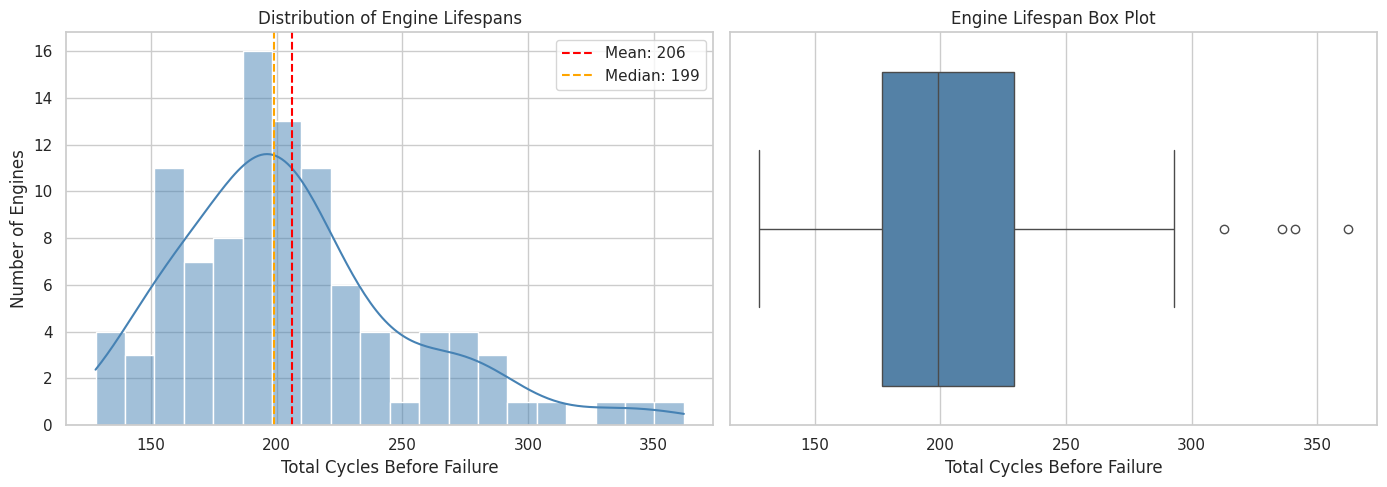

Min lifespan:    128 cycles
Max lifespan:    362 cycles
Mean lifespan:   206.3 cycles
Median lifespan: 199.0 cycles
Std deviation:   46.3 cycles


In [4]:
lifespans = train_df.groupby('unit')['cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(lifespans, bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(lifespans.mean(), color='red', linestyle='--', label=f'Mean: {lifespans.mean():.0f}')
axes[0].axvline(lifespans.median(), color='orange', linestyle='--', label=f'Median: {lifespans.median():.0f}')
axes[0].set_xlabel('Total Cycles Before Failure')
axes[0].set_ylabel('Number of Engines')
axes[0].set_title('Distribution of Engine Lifespans')
axes[0].legend()

# Box plot
sns.boxplot(x=lifespans, ax=axes[1], color='steelblue')
axes[1].set_xlabel('Total Cycles Before Failure')
axes[1].set_title('Engine Lifespan Box Plot')

plt.tight_layout()
plt.show()

print(f"Min lifespan:    {lifespans.min()} cycles")
print(f"Max lifespan:    {lifespans.max()} cycles")
print(f"Mean lifespan:   {lifespans.mean():.1f} cycles")
print(f"Median lifespan: {lifespans.median():.1f} cycles")
print(f"Std deviation:   {lifespans.std():.1f} cycles")

## 3. Sensor Behavior Over Time

**What:** Visualize all 21 sensor readings over the operational life of a sample engine.  
**Why:** Identifying which sensors show clear degradation trends (increasing/decreasing over time) vs. which remain constant or noisy is essential for feature selection. Constant sensors carry no predictive information and should be removed before modeling.  
**Course Reference:** Week 5 — EDA (visualizing data, identifying patterns)

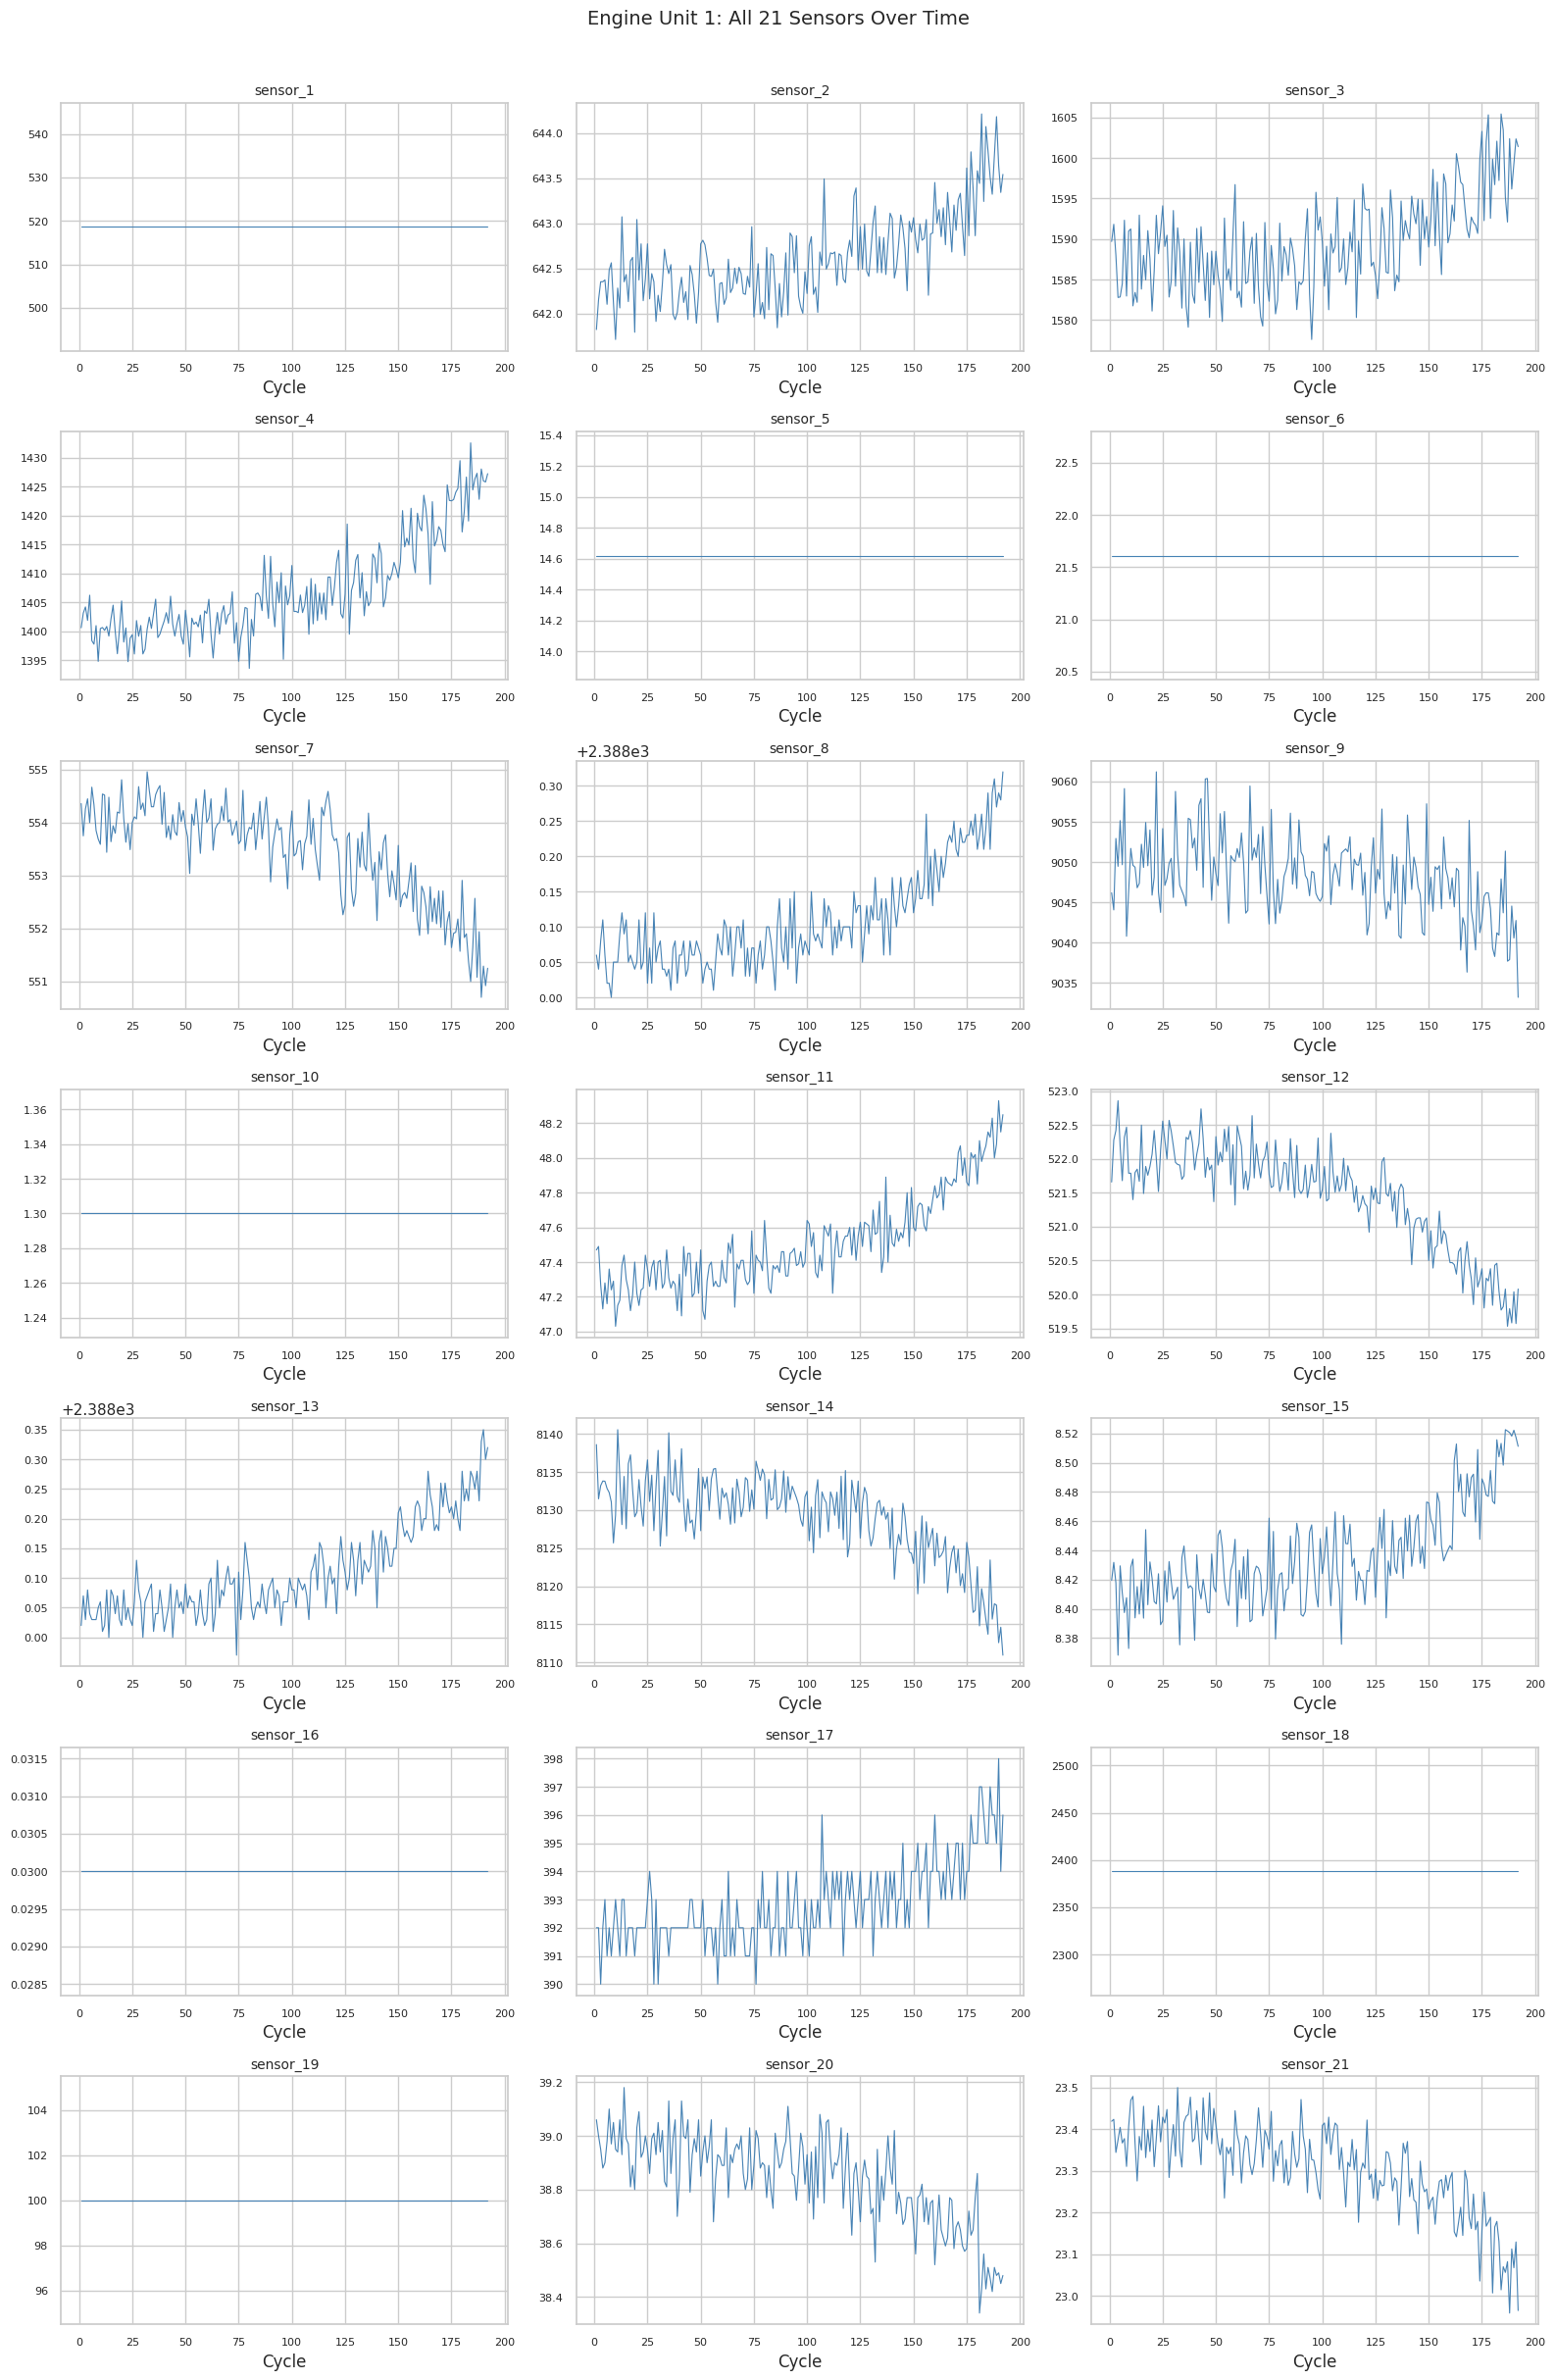

In [5]:
# Plot all 21 sensors for engine unit 1
sample_unit = train_df[train_df['unit'] == 1]
sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]

fig, axes = plt.subplots(7, 3, figsize=(16, 24))
axes = axes.flatten()

for i, sensor in enumerate(sensor_cols):
    axes[i].plot(sample_unit['cycle'], sample_unit[sensor], linewidth=0.8, color='steelblue')
    axes[i].set_title(sensor, fontsize=10)
    axes[i].set_xlabel('Cycle')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Engine Unit 1: All 21 Sensors Over Time', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Multi-Engine Degradation Patterns

**What:** Overlay sensor readings from 5 randomly selected engines to verify degradation consistency.  
**Why:** If sensors show similar degradation trends across different engines, the pattern is systematic (not random noise) and suitable for predictive modeling.  
**Course Reference:** Week 5 — EDA (comparing distributions across groups)

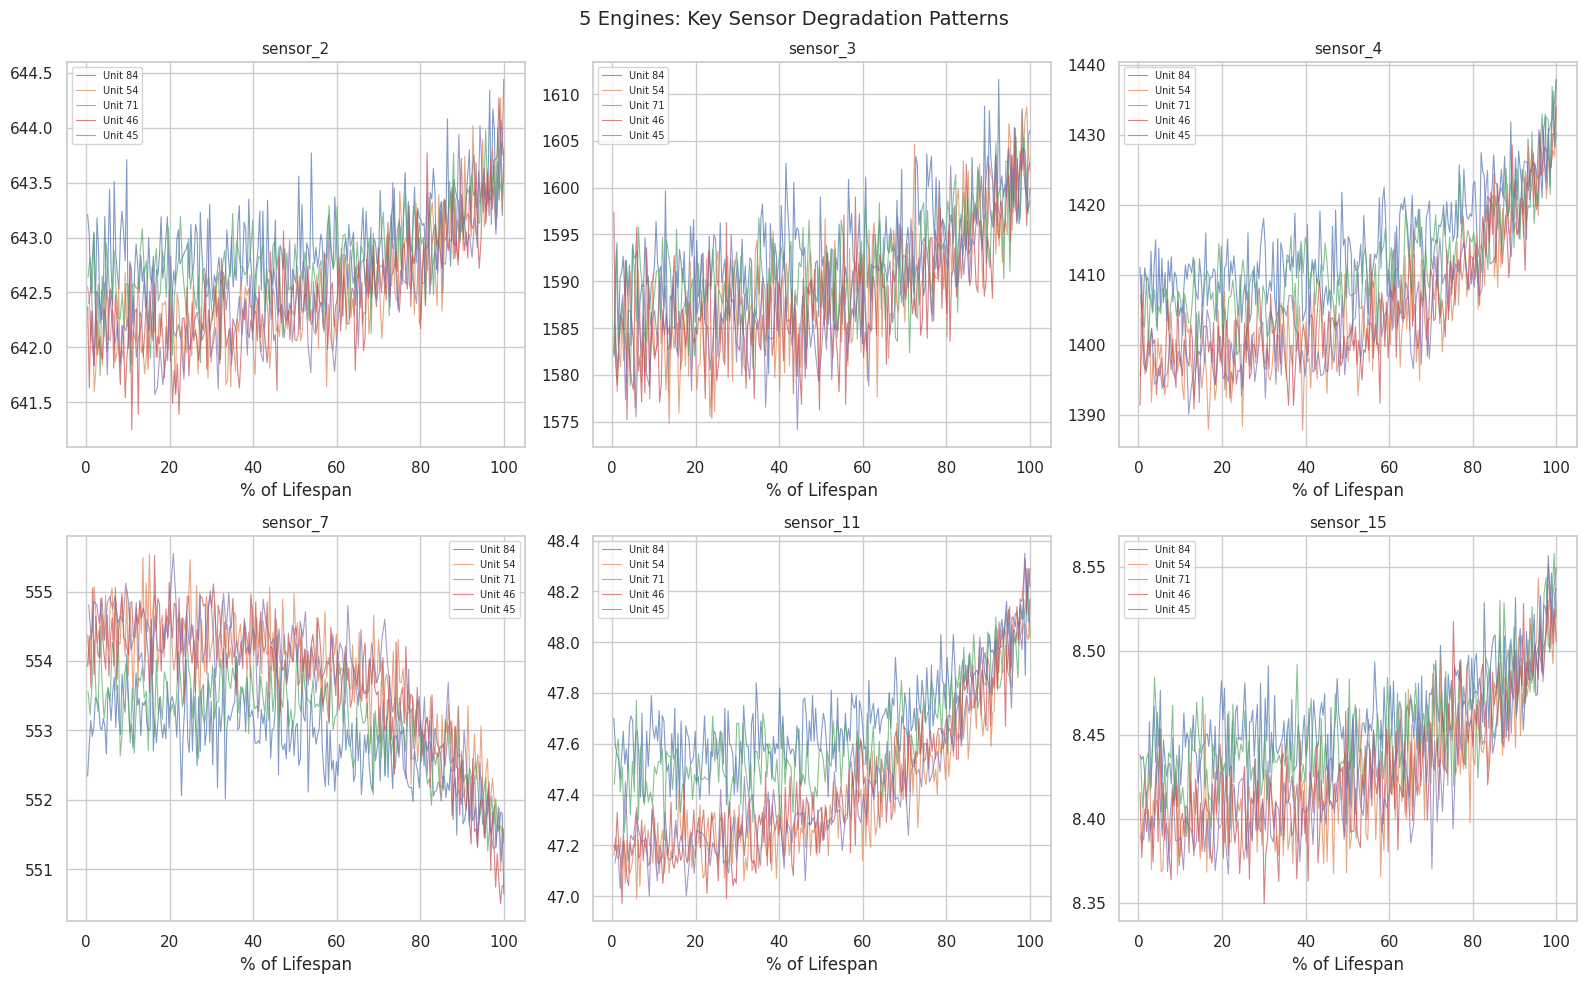

In [6]:
# Select 5 random engines and plot key sensors that showed degradation trends
np.random.seed(42)
sample_units = np.random.choice(train_df['unit'].unique(), 5, replace=False)

# Sensors known to show degradation in CMAPSS FD001
key_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, sensor in enumerate(key_sensors):
    for unit in sample_units:
        unit_data = train_df[train_df['unit'] == unit]
        # Normalize x-axis to % of lifespan for comparison
        pct_life = unit_data['cycle'] / unit_data['cycle'].max() * 100
        axes[i].plot(pct_life, unit_data[sensor], linewidth=0.8, alpha=0.7, label=f'Unit {unit}')
    axes[i].set_title(sensor, fontsize=11)
    axes[i].set_xlabel('% of Lifespan')
    axes[i].legend(fontsize=7)

plt.suptitle('5 Engines: Key Sensor Degradation Patterns', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Identifying Constant and Low-Variance Sensors

**What:** Detect sensors with near-zero variance that carry no predictive information.  
**Why:** Constant sensors add noise to models and can cause numerical issues during normalization (division by zero in StandardScaler). They must be identified and removed before preprocessing.  
**Course Reference:** Week 5 — EDA (identifying features to drop), Week 6 — Classification (feature selection before KNN)

In [7]:
sensor_stats = pd.DataFrame({
    'mean': train_df[sensor_cols].mean(),
    'std': train_df[sensor_cols].std(),
    'min': train_df[sensor_cols].min(),
    'max': train_df[sensor_cols].max(),
    'range': train_df[sensor_cols].max() - train_df[sensor_cols].min()
})

# Flag sensors with very low variance
sensor_stats['constant'] = sensor_stats['std'] < 1e-3

print("=== Sensor Variance Analysis ===")
display(sensor_stats.round(4))

constant_sensors = sensor_stats[sensor_stats['constant']].index.tolist()
useful_sensors = [s for s in sensor_cols if s not in constant_sensors]

print(f"\nConstant/near-constant sensors (will be dropped): {constant_sensors}")
print(f"Useful sensors for modeling ({len(useful_sensors)}): {useful_sensors}")

=== Sensor Variance Analysis ===


,mean,std,min,max,range,constant
sensor_1,518.6700,0.0000,518.6700,518.6700,0.0000,True
sensor_2,642.6809,0.5001,641.2100,644.5300,3.3200,False
sensor_3,1590.5231,6.1311,1571.0400,1616.9100,45.8700,False
sensor_4,1408.9338,9.0006,1382.2500,1441.4900,59.2400,False
sensor_5,14.6200,0.0000,14.6200,14.6200,0.0000,True
sensor_6,21.6098,0.0014,21.6000,21.6100,0.0100,False
sensor_7,553.3677,0.8851,549.8500,556.0600,6.2100,False
sensor_8,2388.0967,0.0710,2387.9000,2388.5600,0.6600,False
sensor_9,9065.2429,22.0829,9021.7300,9244.5900,222.8600,False
sensor_10,1.3000,0.0000,1.3000,1.3000,0.0000,True



Constant/near-constant sensors (will be dropped): ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Useful sensors for modeling (15): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


## 6. Correlation Analysis

**What:** Compute and visualize correlations between useful sensors.  
**Why:** Highly correlated sensors provide redundant information. Understanding correlation structure informs our PCA dimensionality reduction (Week 8) and helps interpret feature importance results.  
**Course Reference:** Week 5 — EDA (correlation heatmaps, `sns.heatmap()`)

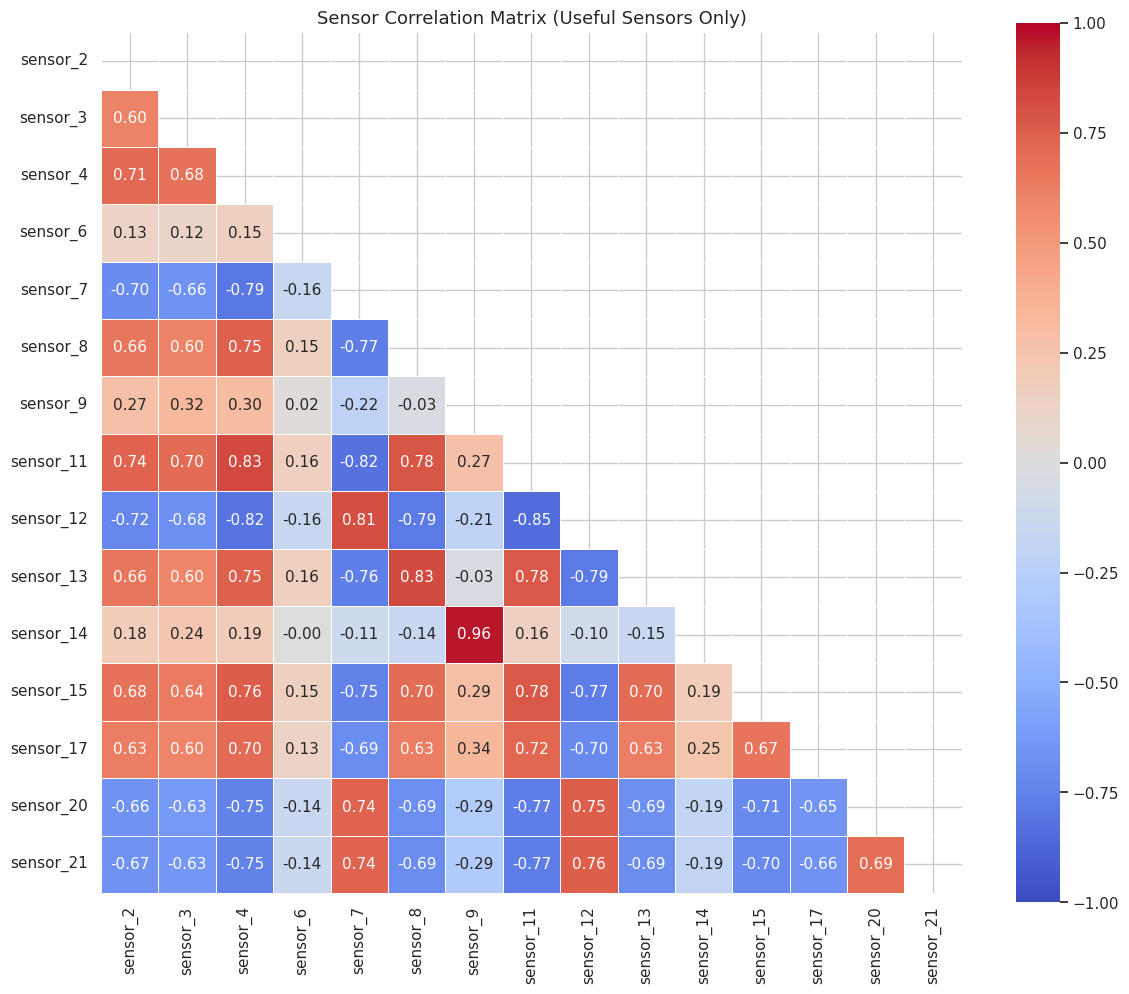


Strongly correlated pairs (|r| > 0.8): 7
  sensor_9 <-> sensor_14: r = 0.963
  sensor_11 <-> sensor_12: r = -0.847
  sensor_4 <-> sensor_11: r = 0.830
  sensor_8 <-> sensor_13: r = 0.826
  sensor_7 <-> sensor_11: r = -0.823
  sensor_4 <-> sensor_12: r = -0.816
  sensor_7 <-> sensor_12: r = 0.813


In [8]:
corr_matrix = train_df[useful_sensors].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Sensor Correlation Matrix (Useful Sensors Only)', fontsize=13)
plt.tight_layout()
plt.show()

# Find strongly correlated pairs
strong_corr = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            strong_corr.append((corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"\nStrongly correlated pairs (|r| > 0.8): {len(strong_corr)}")
for s1, s2, r in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {s1} <-> {s2}: r = {r:.3f}")

## 7. PCA Preview

**What:** Apply PCA to the useful sensor data to understand the intrinsic dimensionality.  
**Why:** With 14 useful sensors, many of which are correlated, PCA can reveal how many independent components capture most of the variance. This preview informs our dimensionality reduction strategy in Notebook 02.  
**Course Reference:** Week 8 — PCA and Factor Analysis (scree plot, explained variance ratio)

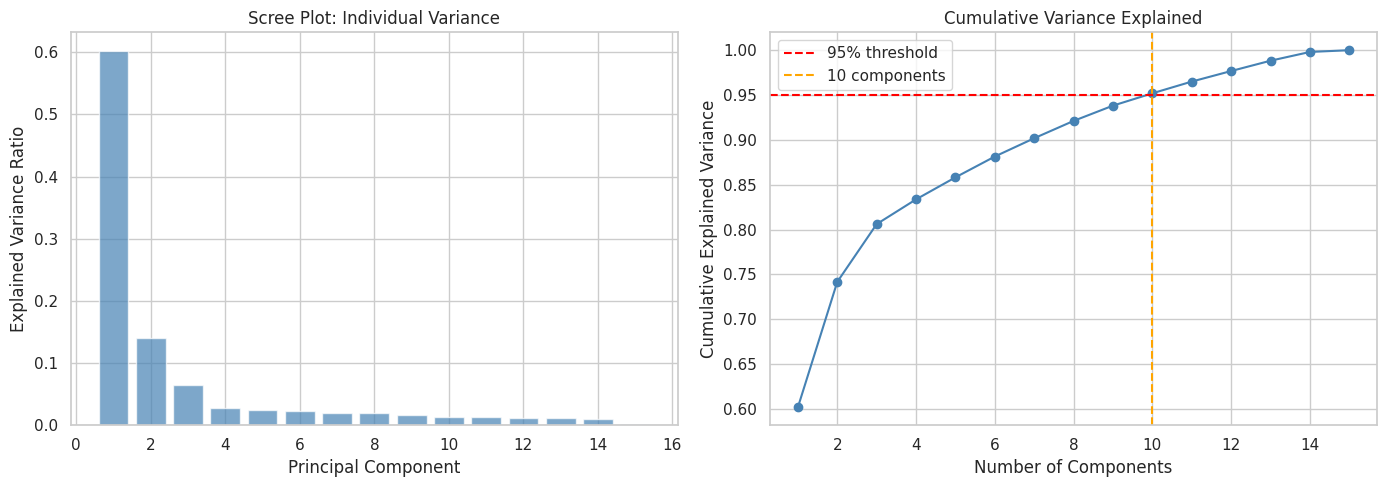

Components needed for 95% variance: 10
Components needed for 99% variance: 14

Variance per component:
  PC1: 0.602 (cumulative: 0.602)
  PC2: 0.140 (cumulative: 0.742)
  PC3: 0.064 (cumulative: 0.806)
  PC4: 0.028 (cumulative: 0.834)
  PC5: 0.025 (cumulative: 0.858)
  PC6: 0.023 (cumulative: 0.881)
  PC7: 0.020 (cumulative: 0.902)
  PC8: 0.019 (cumulative: 0.921)
  PC9: 0.017 (cumulative: 0.938)
  PC10: 0.014 (cumulative: 0.952)
  PC11: 0.013 (cumulative: 0.965)
  PC12: 0.012 (cumulative: 0.977)
  PC13: 0.012 (cumulative: 0.988)
  PC14: 0.010 (cumulative: 0.998)
  PC15: 0.002 (cumulative: 1.000)


In [9]:
# Standardize before PCA (required for meaningful component extraction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train_df[useful_sensors])

pca = PCA()
pca.fit(X_scaled)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot: Individual Variance')

# Cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='steelblue')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
n_95 = np.argmax(cumvar >= 0.95) + 1
axes[1].axvline(x=n_95, color='orange', linestyle='--', label=f'{n_95} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {np.argmax(cumvar >= 0.99) + 1}")
print(f"\nVariance per component:")
for i, (var, cum) in enumerate(zip(pca.explained_variance_ratio_, cumvar)):
    print(f"  PC{i+1}: {var:.3f} (cumulative: {cum:.3f})")

## 8. K-Means Engine Clustering

**What:** Cluster sensor readings to identify distinct degradation stages (healthy -> degrading -> critical).  
**Why:** K-Means can reveal natural groupings in the sensor data that correspond to different phases of engine health. This validates our intuition about degradation progression and informs the failure horizon threshold (ADR-005).  
**Course Reference:** Week 9 — Unsupervised Learning - K-Means (elbow method, silhouette score)

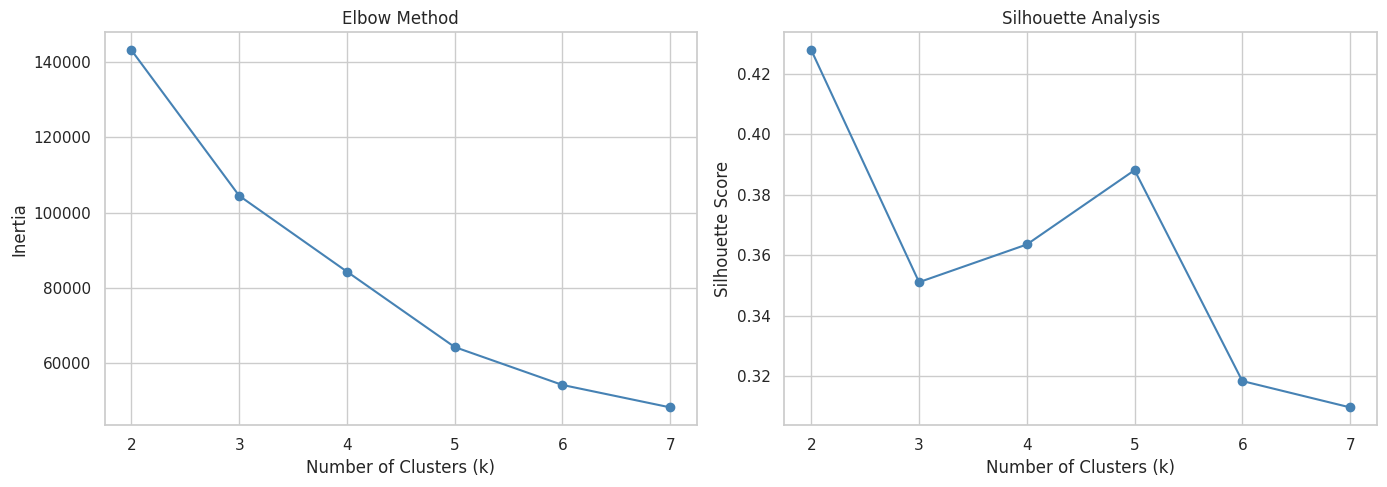

Best k by silhouette score: 2 (score: 0.428)


In [10]:
# Use PCA-reduced data for clustering (first 5 components)
X_pca = PCA(n_components=5).fit_transform(X_scaled)

# Elbow method + Silhouette analysis
k_range = range(2, 8)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouettes, 'o-', color='steelblue')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

# Best k based on silhouette
best_k = list(k_range)[np.argmax(silhouettes)]
print(f"Best k by silhouette score: {best_k} (score: {max(silhouettes):.3f})")

### Cluster Visualization in PCA Space

**What:** Visualize the K-Means clusters (k=3) alongside actual RUL in the first two principal components.  
**Why:** Comparing cluster assignments to true RUL validates whether unsupervised clustering captures meaningful degradation stages without labels.

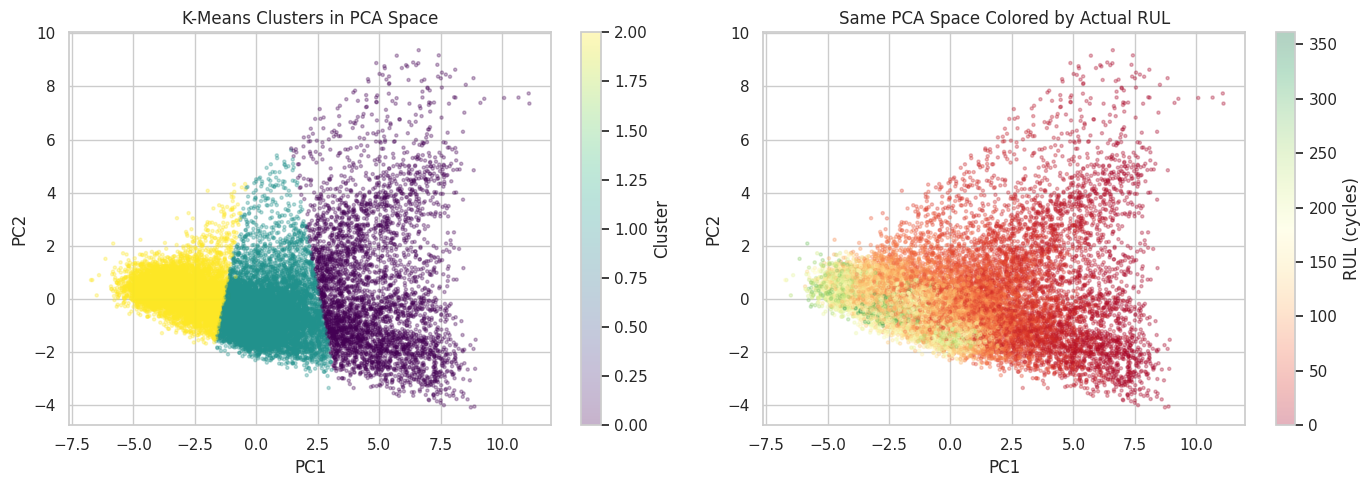


=== Cluster Characteristics ===
Cluster 0: 3,902 samples, mean RUL = 21.9, median RUL = 19.0
Cluster 1: 9,297 samples, mean RUL = 105.7, median RUL = 96.0
Cluster 2: 7,432 samples, mean RUL = 155.6, median RUL = 149.0


In [11]:
# Cluster with k=3 for healthy/degrading/critical interpretation
km_best = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_pca)

# Add RUL for context
max_cycles = train_df.groupby('unit')['cycle'].transform('max')
train_df_temp = train_df.copy()
train_df_temp['rul'] = max_cycles - train_df['cycle']
train_df_temp['cluster'] = cluster_labels

# 2D PCA plot colored by cluster
X_pca_2d = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels,
                           cmap='viridis', alpha=0.3, s=5)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('K-Means Clusters in PCA Space')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=train_df_temp['rul'],
                           cmap='RdYlGn', alpha=0.3, s=5)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Same PCA Space Colored by Actual RUL')
plt.colorbar(scatter2, ax=axes[1], label='RUL (cycles)')

plt.tight_layout()
plt.show()

# Cluster vs RUL summary
print("\n=== Cluster Characteristics ===")
for c in sorted(train_df_temp['cluster'].unique()):
    subset = train_df_temp[train_df_temp['cluster'] == c]
    print(f"Cluster {c}: {len(subset):,} samples, mean RUL = {subset['rul'].mean():.1f}, "
          f"median RUL = {subset['rul'].median():.1f}")

## 9. Operating Condition Analysis

**What:** Check the operational settings to confirm FD001 has a single operating condition.  
**Why:** FD001 should have one operating condition (unlike FD002-FD004). This simplifies our normalization strategy — we can use a single MinMaxScaler instead of per-condition normalization (ADR-006).  
**Course Reference:** Week 3 — Data Wrangling (understanding data structure)

In [12]:
setting_cols = ['setting_1', 'setting_2', 'setting_3']

print("=== Operating Condition Analysis ===")
for col in setting_cols:
    nunique = train_df[col].nunique()
    print(f"\n{col}: {nunique} unique values")
    if nunique <= 10:
        print(f"  Values: {sorted(train_df[col].unique())}")
    else:
        print(f"  Range: [{train_df[col].min():.4f}, {train_df[col].max():.4f}]")
        print(f"  Std: {train_df[col].std():.6f}")

=== Operating Condition Analysis ===

setting_1: 158 unique values
  Range: [-0.0087, 0.0087]
  Std: 0.002187

setting_2: 13 unique values
  Range: [-0.0006, 0.0006]
  Std: 0.000293

setting_3: 1 unique values
  Values: [np.float64(100.0)]


## 10. Test Set RUL Distribution

**What:** Examine the distribution of true RUL values in the test set.  
**Why:** This shows how many engines in the test set are near failure vs. still healthy at the cutoff point. It helps us understand what our model needs to predict and whether the test set is representative.  
**Course Reference:** Week 5 — EDA (distribution analysis)

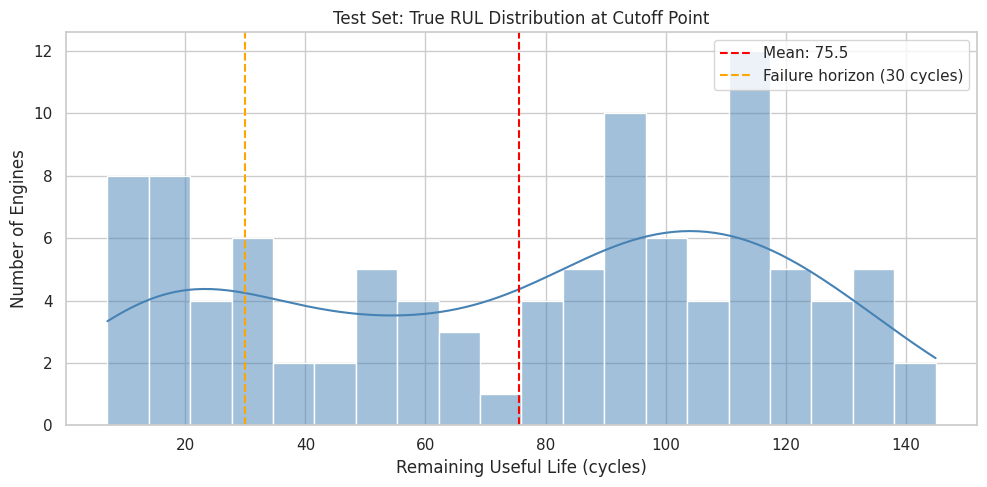

Test set RUL statistics:
  Min: 7
  Max: 145
  Mean: 75.5
  Engines with RUL <= 30 (critical): 25/100
  Engines with RUL > 130 (healthy):  8/100


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(rul_df['rul'], bins=20, kde=True, color='steelblue', ax=ax)
ax.axvline(rul_df['rul'].mean(), color='red', linestyle='--', label=f"Mean: {rul_df['rul'].mean():.1f}")
ax.axvline(30, color='orange', linestyle='--', label='Failure horizon (30 cycles)')
ax.set_xlabel('Remaining Useful Life (cycles)')
ax.set_ylabel('Number of Engines')
ax.set_title('Test Set: True RUL Distribution at Cutoff Point')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Test set RUL statistics:")
print(f"  Min: {rul_df['rul'].min()}")
print(f"  Max: {rul_df['rul'].max()}")
print(f"  Mean: {rul_df['rul'].mean():.1f}")
print(f"  Engines with RUL <= 30 (critical): {(rul_df['rul'] <= 30).sum()}/{len(rul_df)}")
print(f"  Engines with RUL > 130 (healthy):  {(rul_df['rul'] > 130).sum()}/{len(rul_df)}")

## 11. Key Findings Summary

Based on our exploratory analysis:

1. **Dataset structure:** 100 engines, average lifespan ~206 cycles, ranging from 128 to 362 cycles
2. **Constant sensors (will be dropped):** sensors 1, 5, 6, 10, 16, 18, 19 — zero or near-zero variance
3. **Informative sensors:** sensors 2, 3, 4, 7, 8, 11, 12, 13, 14, 15, 17, 20, 21 show clear degradation trends
4. **High correlations:** Several sensor pairs are strongly correlated (|r| > 0.8), supporting PCA dimensionality reduction
5. **PCA:** First ~5 components capture >95% of variance — significant dimensionality reduction possible
6. **K-Means:** 3 clusters map roughly to healthy/degrading/critical engine states, validating degradation progression
7. **Single operating condition:** FD001 settings are effectively constant, simplifying normalization
8. **Test set RUL:** Ranges widely, with some engines near failure and others still healthy

**Next steps (Notebook 02):** Data preparation — RUL label construction, normalization, feature engineering, and train/test splitting.